# Exercise 9 — CH3 
This exercise extends the analysis of the Auto dataset from simple to multiple linear regression, using all available predictors (except name) to model mpg.
We proceed in six parts:
* (a) Explore the dataset visually through a scatterplot matrix of all variables.
* (b) Quantify pairwise relationships by computing the correlation matrix.
* (c) Fit a multiple linear regression via sm.OLS() with all predictors. Assess overall significance (ANOVA), identify which predictors are statistically significant, and interpret individual coefficients.
* (d) Examine diagnostic plots (residuals, leverage, Cook's distance) to check model assumptions and detect outliers or influential points.
* (e) Explore interaction terms between predictors to capture non-additive effects.
* (f) Test non-linear transformations of the predictors $(\log⁡{X},\sqrt{X},
X​^2)$ to improve the fit.

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import seaborn as sns

import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
                        summarize ,
                        poly)

In [2]:

auto = pd.read_csv("../datasets/Auto.data", na_values=["?"], delim_whitespace=True)
auto = auto.dropna()
auto.head()

/var/folders/gq/kz8zkjwj6k1dr27f7byh1x_w0000gn/T/ipykernel_74384/2843700691.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto = pd.read_csv("../datasets/Auto.data", na_values=["?"], delim_whitespace=True)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


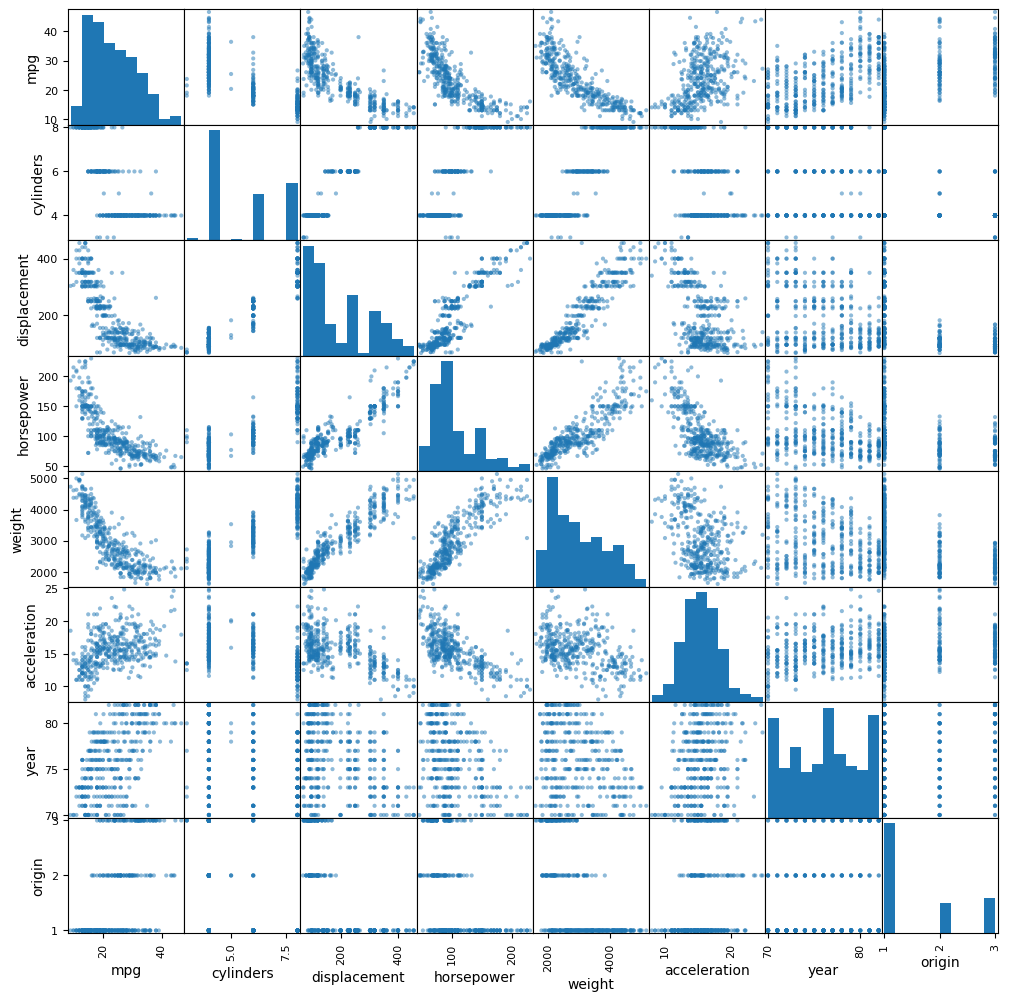

In [3]:
pd.plotting.scatter_matrix(auto, figsize=(12,12));

Text(0.5, 1.0, 'Correlation Matrix')

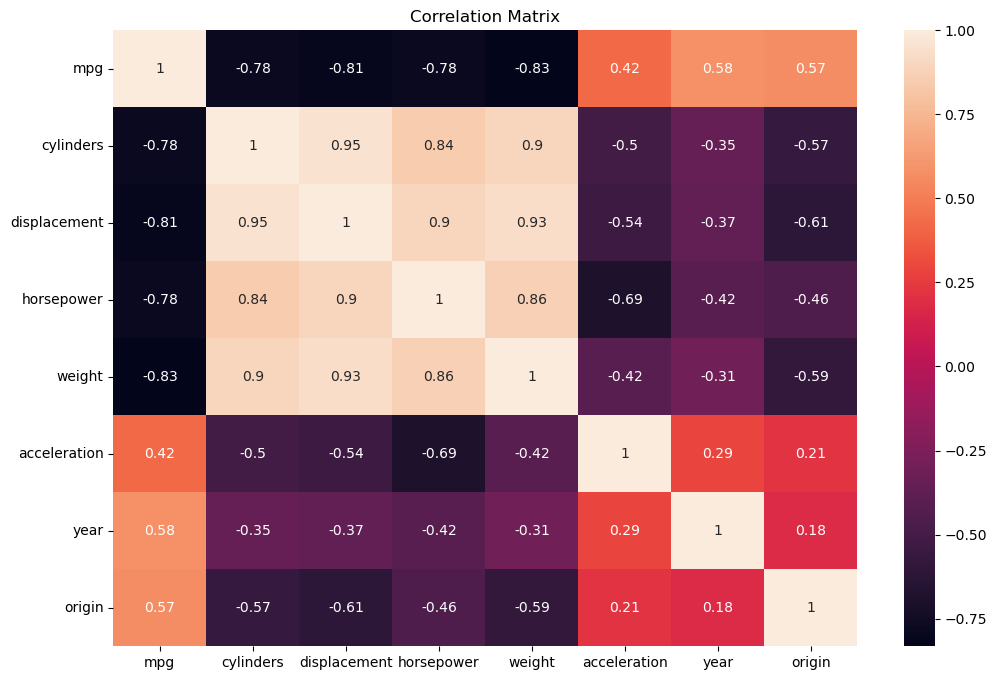

In [4]:
corr_matrix = auto.drop(columns=['name']).corr()

fig,ax = subplots(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True, ax=ax)
ax.set_title("Correlation Matrix") 

In [8]:
predictors = auto.columns.drop(['name','mpg'])
X = MS(predictors).fit_transform(auto)
y = auto['mpg']
model1 = sm.OLS(y,X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [12]:
print("F-score: {0}".format(results1.fvalue))
print("F-p_value: {0}".format(results1.f_pvalue))

F-score: 252.42804529131902
F-p_value: 2.037105930754976e-139


The p-values for these three predictors indicate that they are not statistically relevant or that there is a sort of redundancy / collinearity between variables 
* cylinders (0.128)
* horsepower (0.220)
* acceleration (0.415)

$\beta_{year} \approx 0.75$ means that keeping fixed all the others parameters the efficiency "mpg" increase year by year. 

Text(0, 0.5, 'Residuals')

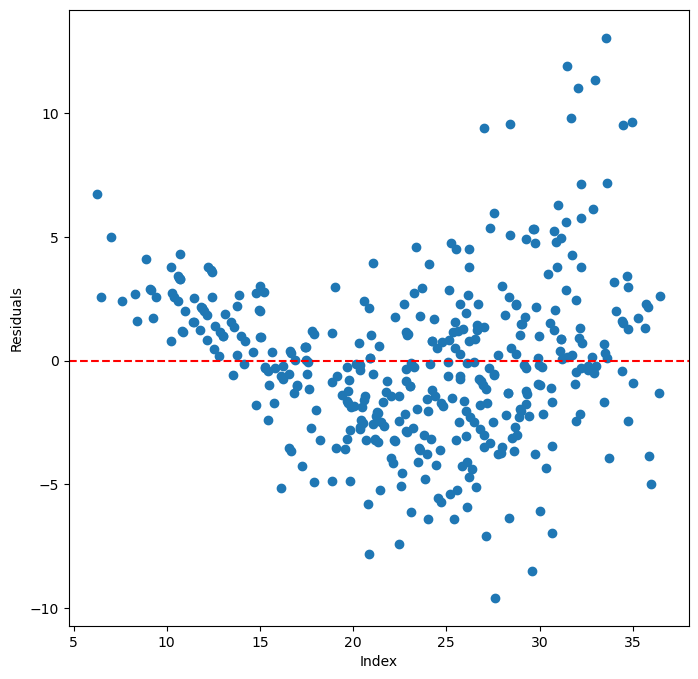

In [22]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results1.fittedvalues,results1.resid)
ax.axhline(0,c="r",ls="--")
ax.set_xlabel("Index")
ax.set_ylabel("Residuals")



We observe that the residual are not evenly distributed but the follow a U shape, this is the hallmark of a non linear relations between $\bold{X}$ and $\bold{y}$.

Text(0, 0.5, 'Leverage')

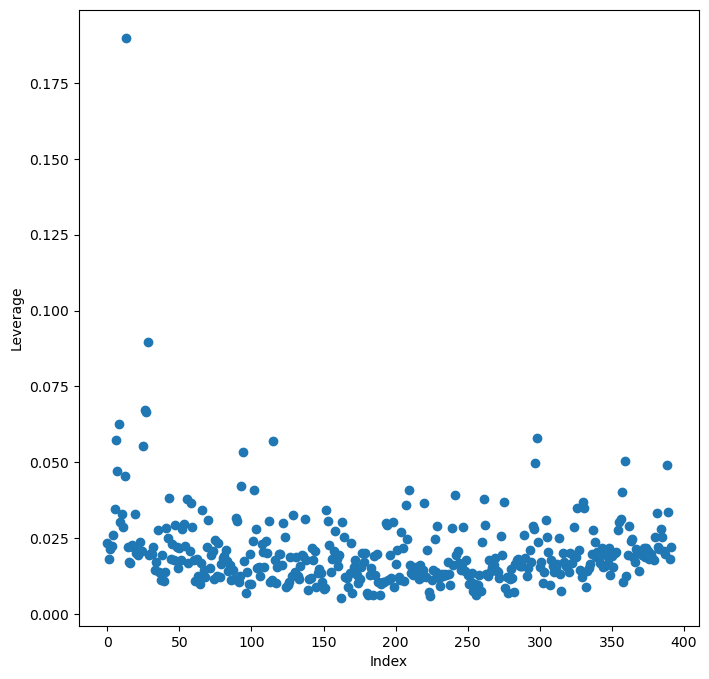

In [24]:
influnce = results1.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]),influnce.hat_matrix_diag)
ax.set_xlabel("Index")
ax.set_ylabel("Leverage")


The are some points with high Leverage, that is to say they are far from the center of the distribution in the predictors space. The are potentially problematic problem because they largely effect the fit. If they were outliers too they would cause problems.  

Now we perform a screen to see which couple of variables is statistically dependent e then we use the result of the screening to create a final model with only relevant predictors. 

In [44]:
terms = list(predictors) + [('horsepower', 'weight'), ('displacement', 'year')]
X = MS(terms).fit_transform(auto)
model_int = sm.OLS(y, X).fit()
summarize(model_int)

print("R² with NO interactions:", results1.rsquared)
print("R² with interactions:", model_int.rsquared)

R² with NO interactions: 0.8214780764810599
R² with interactions: 0.8682838155581584


In [52]:

from unittest import result

auto['horsepower_sqrt'] = np.sqrt(auto["horsepower"]) 
terms = list(predictors) + [poly('displacement', degree=2),
                                poly('horsepower',degree=2),
                                poly('weight',degree=2)]

terms += ['horsepower_sqrt']

X = MS(terms).fit_transform(auto)
model2 = sm.OLS(y,X)
results2 = model2.fit()

print("R² with NO quadratic terms:", results1.rsquared)
print("R² with quadratic terms:", results2.rsquared )

R² with NO quadratic terms: 0.8214780764810599
R² with quadratic terms: 0.8661446309202042
